In [11]:

from typing import TypedDict, Annotated

from dotenv import load_dotenv
from langchain_core.messages import HumanMessage, BaseMessage, AIMessage
from langchain_core.runnables import RunnableConfig
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import InMemorySaver

load_dotenv()

True

In [12]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [13]:
llm = ChatGroq(model="qwen/qwen3-32b", temperature=0.4, reasoning_format="hidden")

In [14]:
def get_conditional_node(state: ChatState) -> str:
    last_message = state["messages"][-1]
    if isinstance(last_message, HumanMessage) and last_message.content.lower().strip() in ["bye", "exit", "quit"]:
        return "end_chat"
    return "continue_chat"

In [15]:
def ask_question(state: ChatState) -> ChatState:
    input_question = input("Type Bye to exit: ")
    human_message = HumanMessage(content=input_question)
    print(f"Human: {human_message.content}")
    return {"messages": [human_message.content]}

In [16]:
def chat_node(state: ChatState, config: RunnableConfig) -> ChatState:
    response = llm.invoke(input=state["messages"])
    print(f"AI: {response.content} \n")
    print(config.get("configurable").get("thread_id"))
    return {"messages": [AIMessage(content=response.content)]}

In [17]:
checkpointer = InMemorySaver()
graph = StateGraph(ChatState)

graph.add_node("ask_question", ask_question)
graph.add_node("chat_node", chat_node)

graph.add_edge(START, "ask_question")
graph.add_conditional_edges("ask_question", get_conditional_node, {"continue_chat": "chat_node", "end_chat": END})
graph.add_edge("chat_node", "ask_question")

workflow = graph.compile(checkpointer= checkpointer)


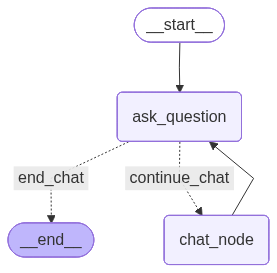

In [18]:
workflow

In [19]:
# def pretty_print_entire_chat(final_state: ChatState):
#     for message in final_state["messages"]:
#         if isinstance(message, HumanMessage):
#             print(f"Human: {message.content}")
#         elif isinstance(message, AIMessage):
#             print(f"AI: {message.content} \n")


In [20]:
config= {"configurable": {"thread_id": "thread_4"}}


initial_state = {"messages": []}
workflow.invoke(input= initial_state, config= config)

Human: Hi

AI: Hello! How can I assist you today? 😊 

thread_4


KeyboardInterrupt: Interrupted by user

In [ ]:
print("=== State History ===")
for snapshot in workflow.get_state_history(config):
    print(f"--- Step {snapshot.metadata['step']} | {snapshot.created_at} ---")
    print("Next:  ", snapshot.next)
    print("Values:", {k: v[:60] + "..." if isinstance(v, str) and len(v) > 60 else v
                     for k, v in snapshot.values.items()})
    print()

